### Data Calibration 

In [43]:
# importing packages
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
# 1. fecting data
ticks = ['ITUB', 'STNE', 'HDB', 'AMX', 'MTNOY'] # picking the asset classs to form the portfolio
data = yf.download(ticks, start = "2018-01-01", end = "2023-01-01")['Close'] # selecting the "Close" column after observing the head of the data
data = data.dropna() # dropping the "na" values

[*********************100%***********************]  5 of 5 completed


In [45]:
# 2. calculating daily log returns 
returns = np.log(data / data.shift(1)).dropna()

# 3. calculating annualized mean and returns and covariance matrix 
annual_returns = returns.mean() * 252
annual_cov = returns.cov() * 252 # forms a covariance matrix since the data is multivariate (and hence we'd like to see how they work with eachother)

# 4. Using Monte-Carlo Simulation to find the efficient frontier
num_portfolios = 10000 # number of simulations 
results = np.zeros((3, num_portfolios)) # creating an array of zeros to allocate results of the portfolio to later
weights_record = [] # initializing a list to place lists containing different weights for each asset class
# risk-free rate 
risk_free_rate = 0.04 

# for loop for generating simulations
for i in range(num_portfolios): 
    weights = np.random.random(len(ticks)) # picking weights based on number of assets in portfolio and using floats between 0 and 1 so that it makes it possible to get like 35.5%
    weights /= np.sum(weights) # normalizing it to sum to 1 
    weights_record.append(weights) # appeding the weights

    # Expected Portfolio Return
    portfolio_return = np.sum(weights * annual_returns) # calculating the expected return of the portfolio

    # Expected Portfolio Volatility (Standard Deviation)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights))) # finding the volatility of the portfolio

    # Sharpe Ratio
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev

    # Storing portfolio characteristics in results created earlier
    results[0,i] = portfolio_std_dev
    results[1,i] = portfolio_return
    results[2,i] = sharpe_ratio

# 5. Extracting the Maximum Sharpe Ratio Portfolio
max_sharpe_idx = np.argmax(results[2]) # getting the index for the maximum sharpe ratio and using that index to pull out the other characteristics 
optimal_std_dev = results[0, max_sharpe_idx] 
optimal_return = results[1, max_sharpe_idx]
optimal_sharpe = results[2, max_sharpe_idx]
optimal_weights = weights_record[max_sharpe_idx]

In [46]:
# printing the results out
print("Standard Markowitz Optimization Results:")
print("-" * 40)
print(f"Maximum Sharpe Ratio: {optimal_sharpe:.4f}")
print(f"Expected Annual Return: {optimal_return:.4f}")
print(f"Expected Annual Volatility: {optimal_std_dev:.4f}")
print("\nOptimal Capital Allocation:") # printing the weights for each asset in the optimized portfolio 
for i in range(len(ticks)):
    print(f"{ticks[i]}: {optimal_weights[i]*100:.2f}%")

Standard Markowitz Optimization Results:
----------------------------------------
Maximum Sharpe Ratio: 0.1750
Expected Annual Return: 0.0907
Expected Annual Volatility: 0.2897

Optimal Capital Allocation:
ITUB: 47.64%
STNE: 35.44%
HDB: 1.22%
AMX: 15.25%
MTNOY: 0.45%


### Visualizing the Efficient Frontier

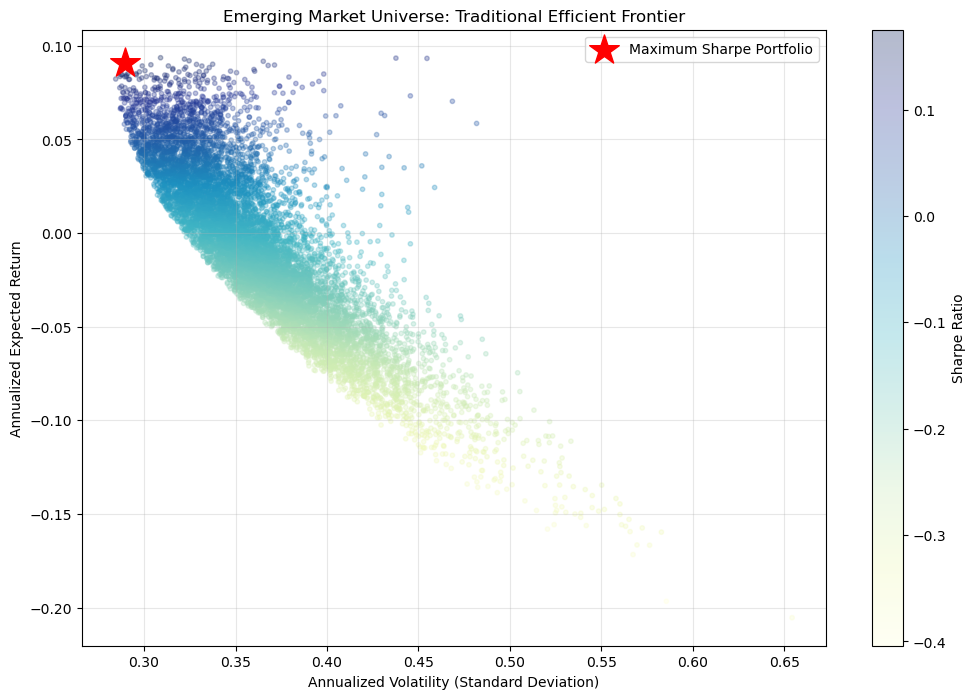

In [47]:
plt.figure(figsize=(12,8)) 
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='YlGnBu', marker='o', s=10, alpha=0.3) # creating a scatter plot using the sharpe ratio as the color along with the others in the results array
plt.colorbar(label='Sharpe Ratio')
plt.scatter(optimal_std_dev, optimal_return, marker='*', color='r', s=500, label='Maximum Sharpe Portfolio') # plotting the optimal return and standard deviation
plt.title('Emerging Market Universe: Traditional Efficient Frontier')
plt.xlabel('Annualized Volatility (Standard Deviation)')
plt.ylabel('Annualized Expected Return')
plt.legend(labelspacing=0.8)
plt.grid(True, alpha=0.3)
plt.savefig("emerging_market_universe_TEF.png", dpi = 300, bbox_inches = 'tight') # saving the plot
plt.show() # showing it

## Shrinking the covariance matrix and Optimizing for better weights 

In [48]:
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

# 1. Cleaning the covariance matrix using ledoit-wolf shrinkage to shrink extreme covarinace estimates toward a structured target to reduce 
# estimation error
lw = LedoitWolf()
shrunk_cov = lw.fit(returns).covariance_ * 252

# 2. Defining the objective function 
# writing a function for the calculation of of the sharpe ratio but negatin it since we're using a minmizing optimizer
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate): # function takes in weights, mean_returns, cov_matrix and risk_free_rate
    p_ret = np.sum(mean_returns * weights) # portfolio return
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) # portfolio variance
    return -(p_ret - risk_free_rate) / p_vol # returning the sharpe multiplied by negative 1

# 3. Defining the Constraints and Bounds
# setting constraints that the sum of all the weights should add up to 1
const = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
# setting bound such that the weights of a single investment isn't more than 30% to encourage diversication and prevent concentration risk
boun = tuple((0.0, 0.30) for asset in range(len(ticks)))

# Setting the initial guess (choosing equal weighting)
init_guess = np.array(len(ticks) * [1. / len(ticks)])

# 4. Optimizing the function using the SLSQP Algorithm
optimized_result = minimize(negative_sharpe, init_guess,
                            args=(annual_returns, shrunk_cov, risk_free_rate),
                            method='SLSQP', bounds=boun, constraints=const)

# 5. Extracting the Robust Weights
robust_weights = optimized_result.x

print("Robust Optimization Results (Ledoit-Wolf Shrinkage + 30% Bound constraint):")
print("-" * 60)
for i in range(len(ticks)):
    print(f"{ticks[i]}: {robust_weights[i]*100:.2f}%")

# Compare Portfolio Volatility
naive_vol = np.sqrt(np.dot(optimal_weights.T, np.dot(annual_cov, optimal_weights)))
robust_vol = np.sqrt(np.dot(robust_weights.T, np.dot(shrunk_cov, robust_weights)))
print(f"\nNaive Portfolio Volatility: {naive_vol:.4f}")
print(f"Robust Portfolio Volatility: {robust_vol:.4f}")

Robust Optimization Results (Ledoit-Wolf Shrinkage + 30% Bound constraint):
------------------------------------------------------------
ITUB: 30.00%
STNE: 30.00%
HDB: 10.00%
AMX: 30.00%
MTNOY: 0.00%

Naive Portfolio Volatility: 0.2897
Robust Portfolio Volatility: 0.3097


In [49]:
# Drawing the weight comparison in a tabular form
print("Weight Comparison")
print(f"{'Asset':<8} | {'Naive Weights':<10} | {'Robust Weight':<10}")
print("_" * 40)
for i in range(len(ticks)):
    print(f"{ticks[i]:<8} | {optimal_weights[i]*100:>10.2f}% | {robust_weights[i]*100:>10.2f}%")

Weight Comparison
Asset    | Naive Weights | Robust Weight
________________________________________
ITUB     |      47.64% |      30.00%
STNE     |      35.44% |      30.00%
HDB      |       1.22% |      10.00%
AMX      |      15.25% |      30.00%
MTNOY    |       0.45% |       0.00%


## Out of Sample testing 

In [50]:
# 1. Downloading the test data to be used and calculating the returns for it 
test_data = yf.download(tickers = ticks, start = '2023-01-01', end= '2025-12-31')['Close']
test_data.dropna(inplace = True)
test_returns = np.log(test_data / test_data.shift(1)).dropna()

# 2. Applying the weights to the test data 
# optimised weights represent the weights that are "naive" and robust weights are the ones found after applying Ledoit-Wolf and optimizing
naive_daily = test_returns.dot(optimal_weights)
robust_daily = test_returns.dot(robust_weights)

# Calculating the returns cummulatively
naive_cum = (1 + naive_daily).cumprod()
robust_cum = (1 + robust_daily).cumprod()

# 3. Creating a function to calculate the maximum drawdom (maximum pain experienced by the investor)
def max_drawdown(cum_returns):
    running_max = cum_returns.cummax() # the highest cummulative return or the peak of the portfolio
    drawdowns = (cum_returns - running_max) / running_max
    return drawdowns.min() # since the numerator for the drawdown is negative i have to return the minimum and the most negative drawdown
                           # corresponds to the maximum peak-to-trough loss

# Calculating performance matrix between the 2 portfolios at the end of test period
# total return 
naive_total_return = naive_cum.iloc[-1] - 1  # subtracting 1 from it because we're assumming we started with
robust_total_return = robust_cum.iloc[-1] - 1 # a capital of 1 so we're taking it out 
# annualized volatility 
naive_vol = naive_daily.std() * np.sqrt(252)
robust_vol = robust_daily.std() * np.sqrt(252)
# maximum drawdown
naive_mdd = max_drawdown(naive_cum)
robust_mdd = max_drawdown(robust_cum)
# Sharpe ratio 
naive_sharpe = (naive_total_return - risk_free_rate) / naive_vol if naive_vol > 0 else 0
robust_sharpe = (robust_total_return - risk_free_rate) / robust_vol if robust_vol > 0 else 0


[*********************100%***********************]  5 of 5 completed


In [51]:
# 4. Placing them in table form
print("Out-of-Sample (OOS) Performance: 2023-2025")
print(f"{'Metric':<15} | {'Naive Portfolio':<18} | {'Robust Portfolio':<18}")
print("_" * 55)
print(f"{'Return':<15} | {naive_total_return*100:>17.2f}% | {robust_total_return*100:>17.2f}%")
print(f"{'Volatility':<15} | {naive_vol*100:17.2f}% | {robust_vol*100:>17.2f}%")
print(f"{'Sharpe Ratio':<15} |  {naive_sharpe:17.2f} | {robust_sharpe:>17.2f}")
print(f"{'Max Drawdown':<15} | {naive_mdd*100:>17.2f}% | {robust_mdd*100:>17.2f}%")

Out-of-Sample (OOS) Performance: 2023-2025
Metric          | Naive Portfolio    | Robust Portfolio  
_______________________________________________________
Return          |             17.05% |             26.83%
Volatility      |             18.10% |             19.52%
Sharpe Ratio    |               0.72 |              1.17
Max Drawdown    |            -28.83% |            -29.06%


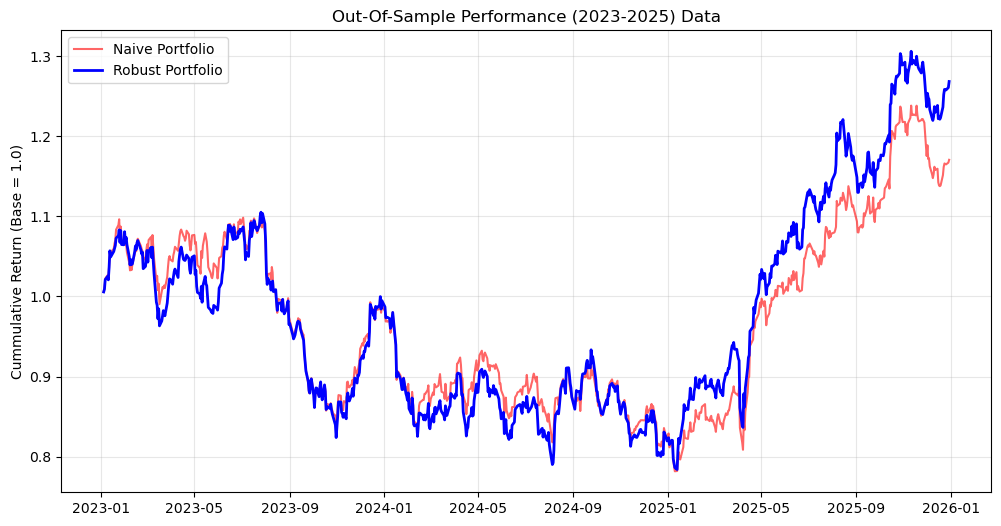

In [52]:
# 5. Visualizing the Equity Curve
plt.figure(figsize=(12,6))
plt.plot(naive_cum.index, naive_cum, label='Naive Portfolio', color = 'red', alpha=0.6)
plt.plot(robust_cum.index, robust_cum, label='Robust Portfolio', color = 'blue', linewidth=2)
plt.title('Out-Of-Sample Performance (2023-2025) Data')
plt.ylabel('Cummulative Return (Base = 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("equity_curve.png",dpi=300, bbox_inches = 'tight')
plt.show()